# NYC Yellow Taxi Trip Analysis

In [ ]:
"""
# NYC Yellow Taxi Trip Analysis

This project analyzes NYC Yellow Taxi trip data to identify:
- Trip behavior patterns
- Payment trends
- Traffic characteristics
- Factors affecting total fare
- Fare prediction using machine learning
"""

'\n# NYC Yellow Taxi Trip Analysis\n\nThis project analyzes NYC Yellow Taxi trip data to identify:\n- Trip behavior patterns\n- Payment trends\n- Traffic characteristics\n- Factors affecting total fare\n- Fare prediction using machine learning\n'

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal
from scipy.stats import chi2_contingency

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error,r2_score

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)


In [2]:
from google.colab import auth
auth.authenticate_user()

In [3]:
from google.cloud import bigquery
client = bigquery.Client(project="my_project")

# QUERY DATA

In [4]:
query = """
SELECT *
FROM `my_project.my_dataset.my_table`
"""

df_full = client.query(query).to_dataframe()

In [ ]:
print(df_full.shape)
df_full.head()

(6628926, 27)


,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,rate_code,store_and_fwd_flag,dropoff_longitude,...,imp_surcharge,total_amount,distance_km,pickup_date,pickup_hour,dropoff_date,dropoff_hour,trip_duration_minutes,speed_kmh,speed_cat
0,2,2016-06-16 00:40:37+00:00,2016-06-16 00:46:44+00:00,1,0.76,-74.00,40.75,1,N,-73.99,...,0.30,7.30,1.22,2016-06-16,0,2016-06-16,0,6.12,12.00,normal
1,2,2016-06-18 00:09:57+00:00,2016-06-18 00:11:24+00:00,1,0.40,-73.95,40.77,1,N,-73.95,...,0.30,4.80,0.64,2016-06-18,0,2016-06-18,0,1.45,26.64,normal
2,1,2016-06-18 00:06:40+00:00,2016-06-18 00:18:51+00:00,2,1.40,-73.99,40.76,1,N,-73.97,...,0.30,10.80,2.25,2016-06-18,0,2016-06-18,0,12.18,11.10,normal
3,2,2016-06-24 00:42:16+00:00,2016-06-24 00:47:09+00:00,1,0.80,-73.99,40.73,1,N,-74.01,...,0.30,6.80,1.29,2016-06-24,0,2016-06-24,0,4.88,15.82,normal
4,1,2016-04-28 00:22:20+00:00,2016-04-28 00:30:38+00:00,2,1.30,-73.97,40.76,1,N,-73.99,...,0.30,8.80,2.09,2016-04-28,0,2016-04-28,0,8.30,15.12,normal


## DATA LOADING

In [5]:
df_taxi = df_full.copy()

In [6]:
# Datetime conversion
df_taxi['pickup_datetime'] = pd.to_datetime(df_taxi['pickup_datetime'])
df_taxi['dropoff_datetime'] = pd.to_datetime(df_taxi['dropoff_datetime'])

In [7]:
# Time features
df_taxi['day_name'] = df_taxi['pickup_datetime'].dt.day_name()
df_taxi['day_order'] = df_taxi['pickup_datetime'].dt.weekday + 1
df_taxi['is_weekend'] = (
    df_taxi['pickup_datetime'].dt.weekday >= 5
).astype(int)

In [8]:
# Convert categorical columns
cat_cols = [
    'payment_type',
    'store_and_fwd_flag',
    'speed_cat',
    'vendor_id',
    'rate_code',
    'is_weekend'
]

df_taxi[cat_cols] = df_taxi[cat_cols].astype('category')

In [ ]:
df_taxi.head()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,rate_code,store_and_fwd_flag,dropoff_longitude,...,pickup_date,pickup_hour,dropoff_date,dropoff_hour,trip_duration_minutes,speed_kmh,speed_cat,day_name,day_order,is_weekend
0,2,2016-06-16 00:40:37+00:00,2016-06-16 00:46:44+00:00,1,0.76,-74.00,40.75,1,N,-73.99,...,2016-06-16,0,2016-06-16,0,6.12,12.00,normal,Thursday,4,0
1,2,2016-06-18 00:09:57+00:00,2016-06-18 00:11:24+00:00,1,0.40,-73.95,40.77,1,N,-73.95,...,2016-06-18,0,2016-06-18,0,1.45,26.64,normal,Saturday,6,1
2,1,2016-06-18 00:06:40+00:00,2016-06-18 00:18:51+00:00,2,1.40,-73.99,40.76,1,N,-73.97,...,2016-06-18,0,2016-06-18,0,12.18,11.10,normal,Saturday,6,1
3,2,2016-06-24 00:42:16+00:00,2016-06-24 00:47:09+00:00,1,0.80,-73.99,40.73,1,N,-74.01,...,2016-06-24,0,2016-06-24,0,4.88,15.82,normal,Friday,5,0
4,1,2016-04-28 00:22:20+00:00,2016-04-28 00:30:38+00:00,2,1.30,-73.97,40.76,1,N,-73.99,...,2016-04-28,0,2016-04-28,0,8.30,15.12,normal,Thursday,4,0


In [9]:
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

df_taxi['day_name'] = pd.Categorical(
    df_taxi['day_name'],
    categories=day_order,
    ordered=True
)

# DATA PREPARATION

In [10]:
df_ml = df_taxi.copy()

# Drop unnecessary columns
drop_cols2= ['pickup_datetime', 'dropoff_datetime']

df_ml = df_ml.drop(columns=drop_cols2)

In [11]:
df_ml.head()

,vendor_id,passenger_count,trip_distance,pickup_longitude,pickup_latitude,rate_code,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,...,pickup_date,pickup_hour,dropoff_date,dropoff_hour,trip_duration_minutes,speed_kmh,speed_cat,day_name,day_order,is_weekend
0,1,1,1.80,-74.00,40.73,1,N,-73.98,40.76,2,...,2016-06-13,0,2016-06-13,0,4.83,35.96,normal,Monday,1,0
1,2,2,1.55,-73.99,40.72,1,N,-74.01,40.71,2,...,2016-06-21,0,2016-06-21,0,6.93,21.59,normal,Tuesday,2,0
2,2,2,3.46,-73.99,40.76,1,N,-73.97,40.80,2,...,2016-05-04,0,2016-05-04,0,12.08,27.65,normal,Wednesday,3,0
3,2,2,3.96,-73.97,40.76,1,N,-73.96,40.80,2,...,2016-05-04,0,2016-05-04,0,16.63,22.99,normal,Wednesday,3,0
4,1,1,2.40,-74.01,40.72,1,N,-73.98,40.72,2,...,2016-05-08,0,2016-05-08,0,11.05,20.97,normal,Sunday,7,1


In [ ]:
df_ml.describe()

,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,fare_amount,extra,mta_tax,tip_amount,tolls_amount,imp_surcharge,total_amount,distance_km,pickup_hour,dropoff_hour,trip_duration_minutes,speed_kmh,day_order
count,6628926.00,6628926.00,6628926.00,6628926.00,6628926.00,6628926.00,6628926.00,6628926.00,6628926.00,6628926.00,6628926.00,6628926.00,6628926.00,6628926.00,6628926.00,6628926.00,6628926.00,6628926.00,6628926.00
mean,1.66,2.66,-73.98,40.75,-73.95,40.74,11.93,0.32,0.50,1.65,0.21,0.30,14.92,4.29,13.62,13.61,13.26,18.59,4.05
std,1.31,2.85,0.09,0.05,1.22,0.67,8.37,0.37,0.01,1.93,1.06,0.00,10.22,4.59,6.40,6.48,9.19,9.33,1.95
min,1.00,0.01,-131.82,-44.57,-115.17,0.00,2.50,0.00,0.00,0.00,0.00,0.00,3.00,0.02,0.00,0.00,1.00,0.20,1.00
25%,1.00,1.00,-73.99,40.74,-73.99,40.74,6.50,0.00,0.50,0.00,0.00,0.30,8.75,1.61,9.00,9.00,6.60,12.31,2.00
50%,1.00,1.70,-73.98,40.75,-73.98,40.75,9.50,0.00,0.50,1.32,0.00,0.30,11.76,2.74,14.00,14.00,10.88,16.62,4.00
75%,2.00,3.00,-73.97,40.77,-73.96,40.77,14.00,0.50,0.50,2.35,0.00,0.30,17.25,4.83,19.00,19.00,17.40,22.42,6.00
max,9.00,18.64,118.41,59.35,0.00,48.01,55.00,1.00,0.50,12.00,6.00,0.32,73.34,30.00,23.00,23.00,60.00,72.00,7.00


In [ ]:
# Duplicate data
duplicate_pct = (df_ml.duplicated().sum() / len(df_ml)) * 100

duplicate_pct

np.float64(0.0)

In [ ]:
df_ml.shape

(6628926, 28)

## EXPLORATORY DATA ANALYSIS

### NUMERICAL ANALYSIS

In [ ]:
corr = df_ml.select_dtypes(include=np.number).corr()

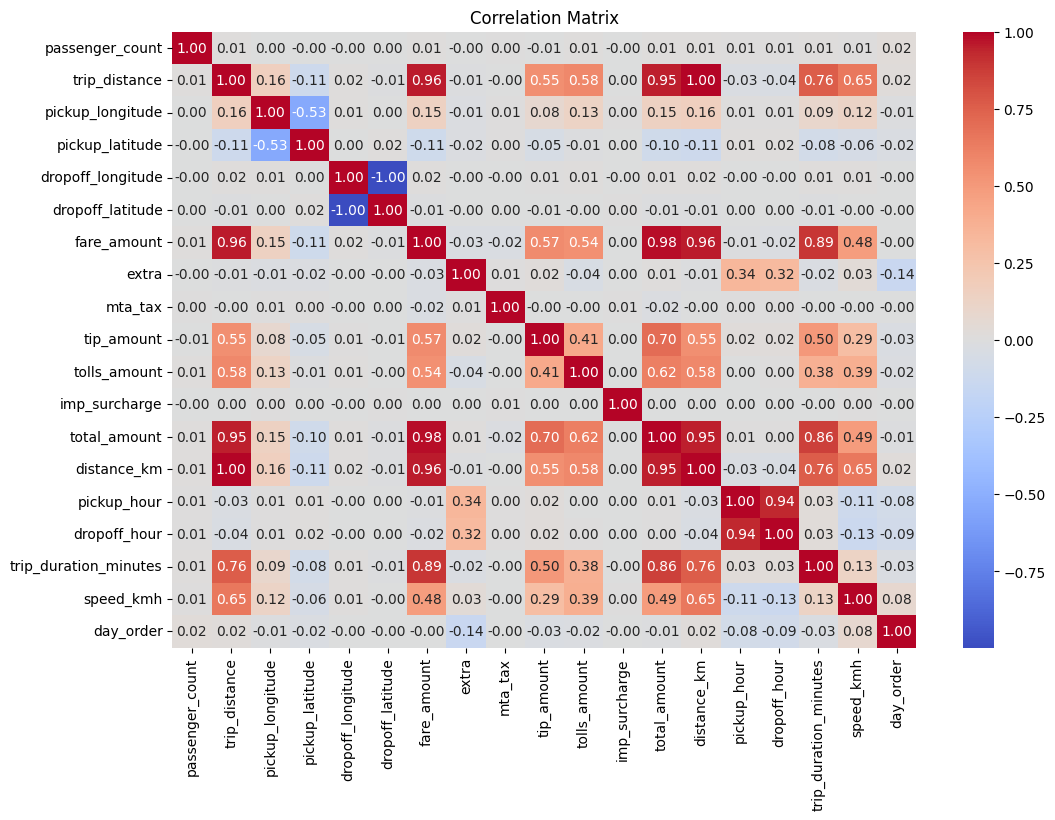

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

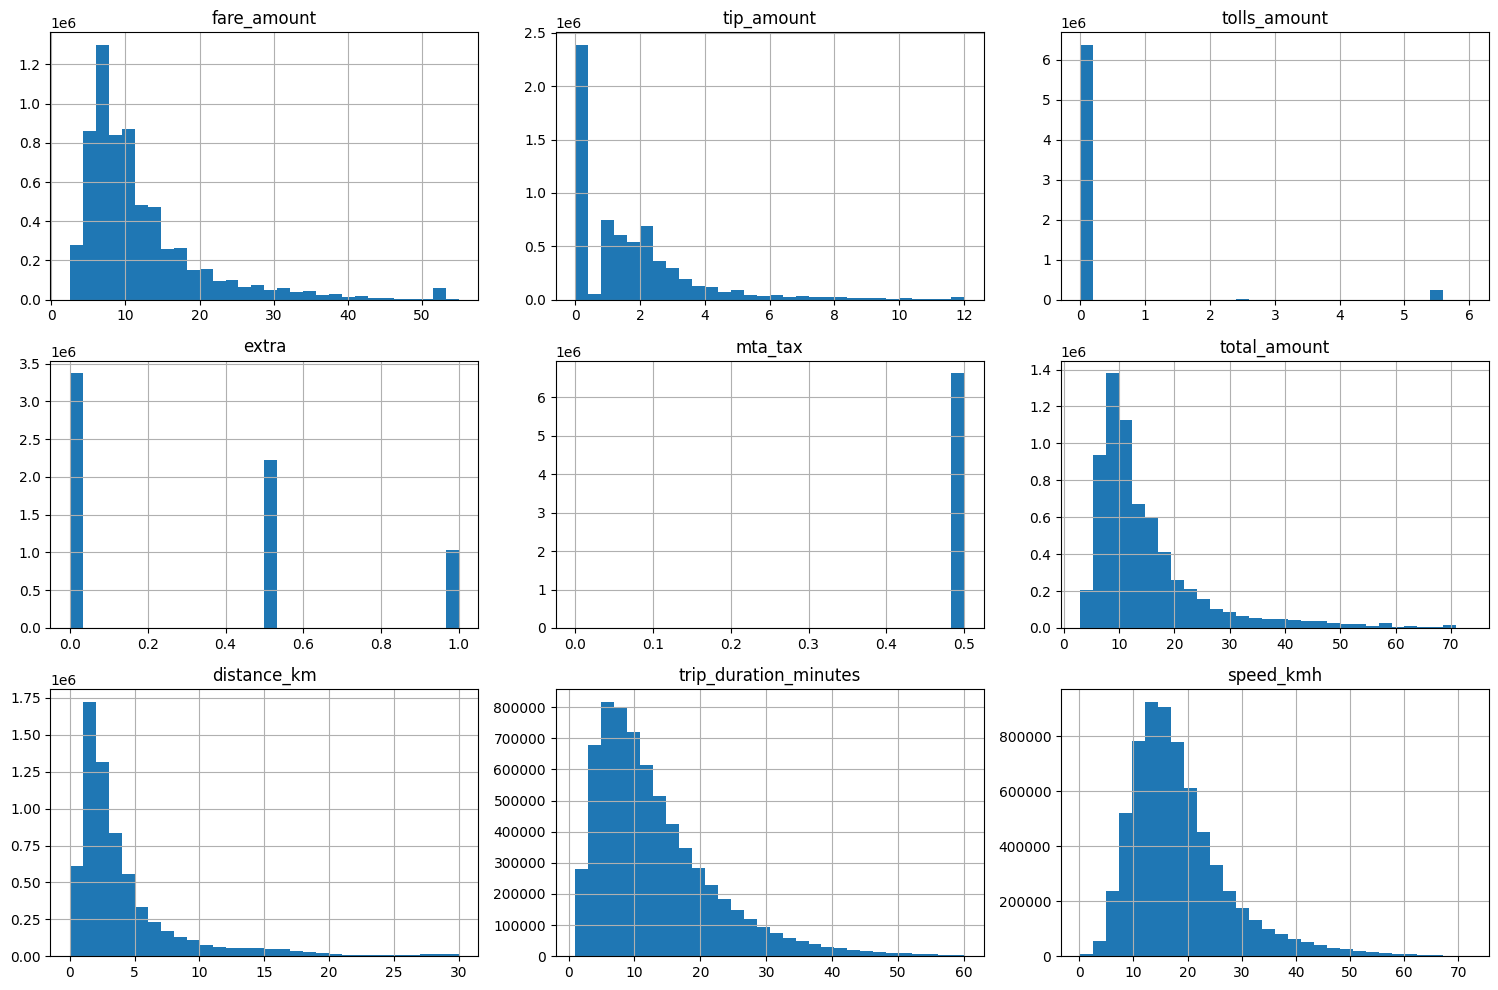

In [ ]:
num_cols = [
    'fare_amount',
    'tip_amount',
    'tolls_amount',
    'extra',
    'mta_tax',
    'total_amount',
    'distance_km',
    'trip_duration_minutes',
    'speed_kmh'
]

df_ml[num_cols].hist(
    figsize=(15,10),
    bins=30
)

plt.tight_layout()
plt.show()

In [ ]:
print(df_ml['speed_cat'].value_counts())

speed_cat
normal                 5723748
moderate_congestion     821726
severe_congestion        62950
extreme                  20502
Name: count, dtype: int64


In [ ]:
print(df_ml['payment_type'].value_counts())

payment_type
1    4413689
2    2191941
3      16734
4       6562
Name: count, dtype: int64


In [ ]:
df_ml.describe()

,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,fare_amount,extra,mta_tax,tip_amount,tolls_amount,imp_surcharge,total_amount,distance_km,pickup_hour,dropoff_hour,trip_duration_minutes,speed_kmh,day_order
count,6628926.00,6628926.00,6628926.00,6628926.00,6628926.00,6628926.00,6628926.00,6628926.00,6628926.00,6628926.00,6628926.00,6628926.00,6628926.00,6628926.00,6628926.00,6628926.00,6628926.00,6628926.00,6628926.00
mean,1.66,2.66,-73.98,40.75,-73.95,40.74,11.93,0.32,0.50,1.65,0.21,0.30,14.92,4.29,13.62,13.61,13.26,18.59,4.05
std,1.31,2.85,0.09,0.05,1.22,0.67,8.37,0.37,0.01,1.93,1.06,0.00,10.22,4.59,6.40,6.48,9.19,9.33,1.95
min,1.00,0.01,-131.82,-44.57,-115.17,0.00,2.50,0.00,0.00,0.00,0.00,0.00,3.00,0.02,0.00,0.00,1.00,0.20,1.00
25%,1.00,1.00,-73.99,40.74,-73.99,40.74,6.50,0.00,0.50,0.00,0.00,0.30,8.75,1.61,9.00,9.00,6.60,12.31,2.00
50%,1.00,1.70,-73.98,40.75,-73.98,40.75,9.50,0.00,0.50,1.32,0.00,0.30,11.76,2.74,14.00,14.00,10.88,16.62,4.00
75%,2.00,3.00,-73.97,40.77,-73.96,40.77,14.00,0.50,0.50,2.35,0.00,0.30,17.25,4.83,19.00,19.00,17.40,22.42,6.00
max,9.00,18.64,118.41,59.35,0.00,48.01,55.00,1.00,0.50,12.00,6.00,0.32,73.34,30.00,23.00,23.00,60.00,72.00,7.00


### CATEGORICAL ANALYSIS

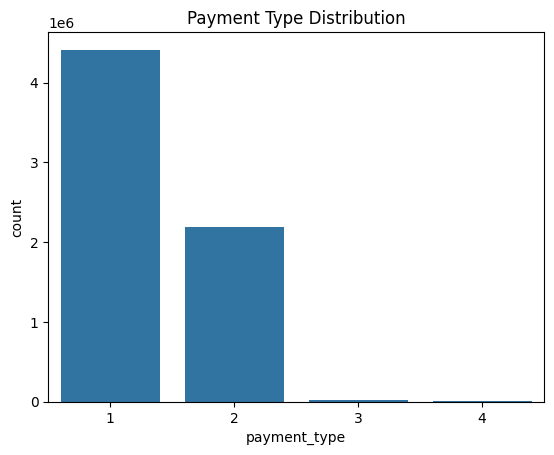

In [ ]:
# payment type distribution
sns.countplot(
    data=df_ml,
    x='payment_type'
)

plt.title('Payment Type Distribution')
plt.show()

### TRIPS PATTERN

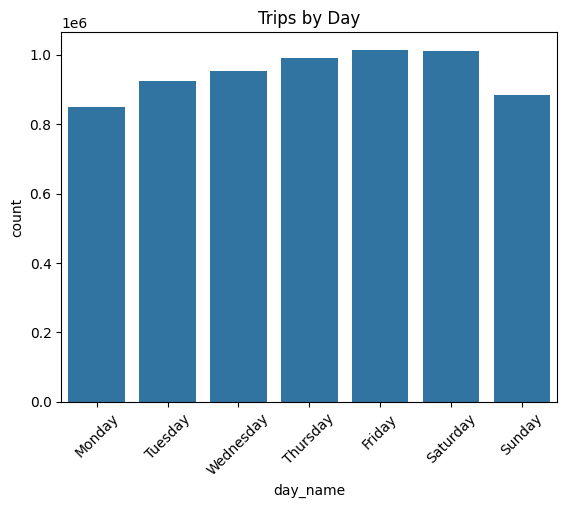

In [ ]:
sns.countplot(
    data=df_ml,
    x='day_name',
    order=[
        'Monday',
        'Tuesday',
        'Wednesday',
        'Thursday',
        'Friday',
        'Saturday',
        'Sunday'
    ]
)

plt.title('Trips by Day')
plt.xticks(rotation=45)
plt.show()

In [ ]:
print(df_ml['day_name'].value_counts())

day_name
Friday       1014440
Saturday     1009562
Thursday      991046
Wednesday     953798
Tuesday       925545
Sunday        883804
Monday        850731
Name: count, dtype: int64


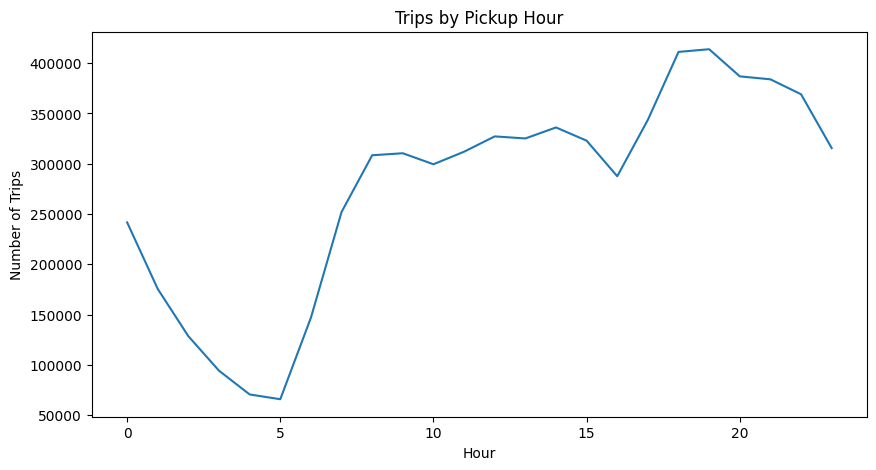

In [ ]:
# HOURLY PATTERN TRIP
hourly_trip = df_ml.groupby('pickup_hour').size()

hourly_trip.plot(figsize=(10,5))

plt.title('Trips by Pickup Hour')
plt.xlabel('Hour')
plt.ylabel('Number of Trips')
plt.show()

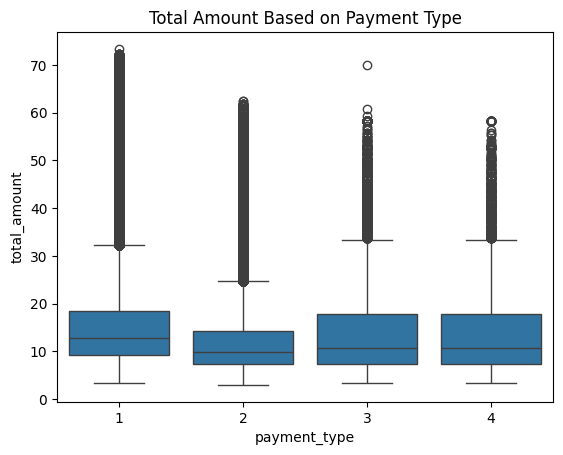

In [ ]:
# PAYMENT TYPE DISTRIBUTION
sns.boxplot(
    data=df_ml,
    x='payment_type',
    y='total_amount'
)

plt.title('Total Amount Based on Payment Type')
plt.show()

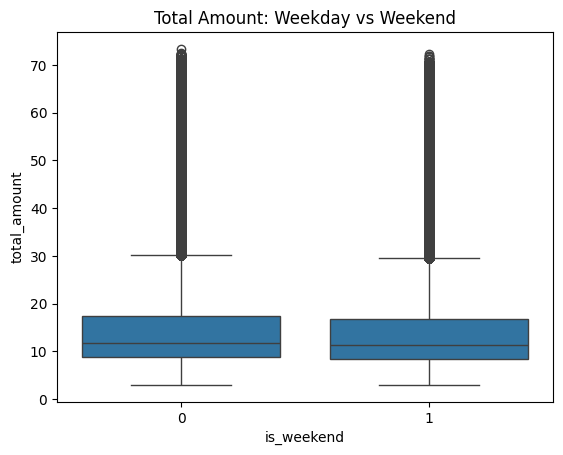

In [ ]:
# BOXPLOT TOTAL AMOUNT : WEEKDAY VS WEEKEND
sns.boxplot(
    data=df_ml,
    x='is_weekend',
    y='total_amount'
)

plt.title('Total Amount: Weekday vs Weekend')
plt.show()

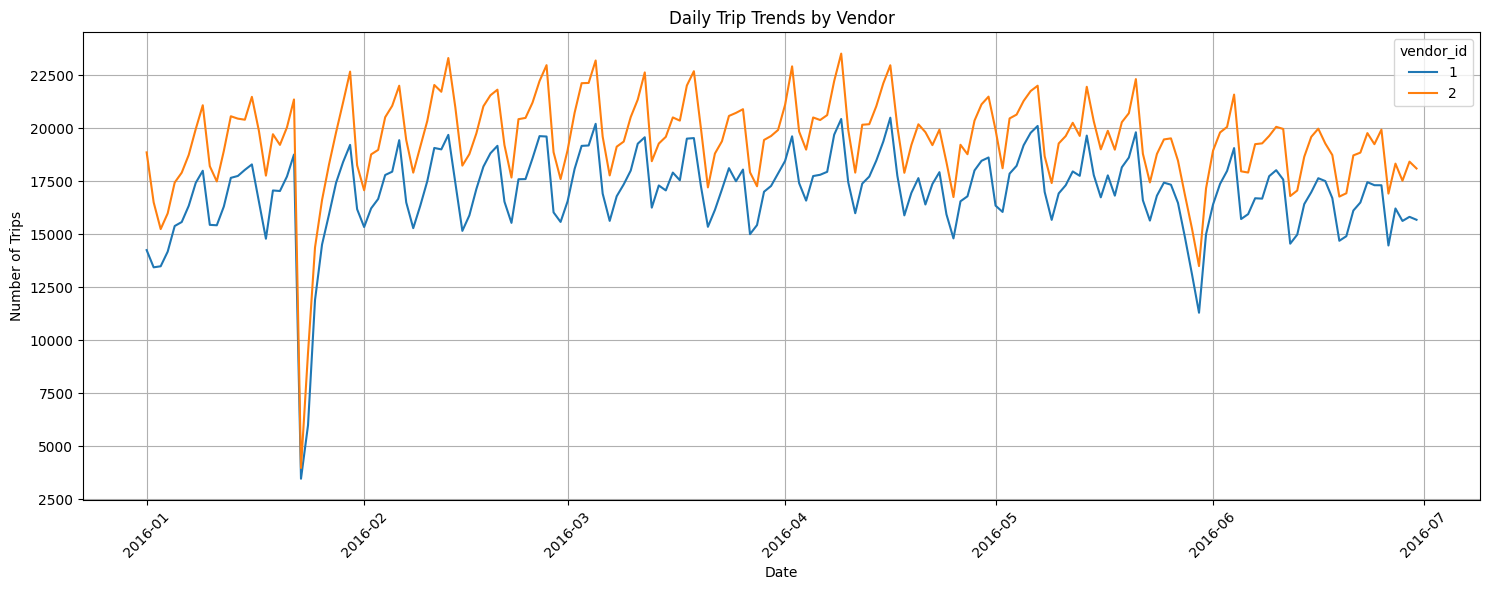

In [18]:
# Count trips per day by vendor
daily_vendor = (
    df_ml
    .groupby(['pickup_date', 'vendor_id'])
    .size()
    .reset_index(name='trip_count')
)

# Plot
plt.figure(figsize=(15,6))

sns.lineplot(
    data=daily_vendor,
    x='pickup_date',
    y='trip_count',
    hue='vendor_id'
)

plt.title('Daily Trip Trends by Vendor')
plt.xlabel('Date')
plt.ylabel('Number of Trips')

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

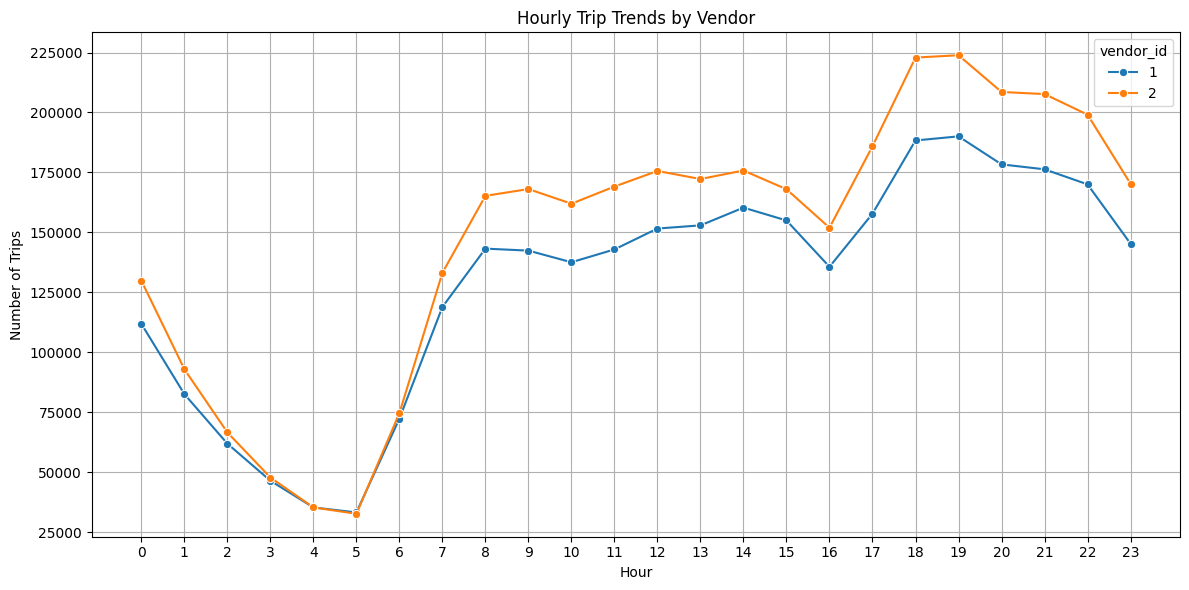

In [17]:
# Count trips per hour by vendor
hourly_vendor = (
    df_ml
    .groupby(['pickup_hour', 'vendor_id'])
    .size()
    .reset_index(name='trip_count')
)

# Plot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=hourly_vendor,
    x='pickup_hour',
    y='trip_count',
    hue='vendor_id',
    marker='o'
)

plt.title('Hourly Trip Trends by Vendor')
plt.xlabel('Hour')
plt.ylabel('Number of Trips')

plt.xticks(range(0,24))
plt.grid(True)

plt.tight_layout()
plt.show()

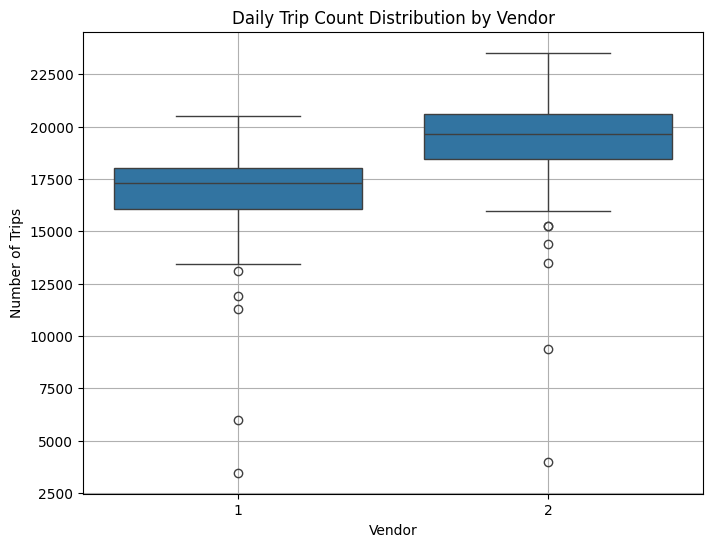

In [19]:
# Count daily trips by vendor
daily_trip = (
    df_ml
    .groupby(['pickup_date', 'vendor_id'])
    .size()
    .reset_index(name='trip_count')
)

# Boxplot
plt.figure(figsize=(8,6))

sns.boxplot(
    data=daily_trip,
    x='vendor_id',
    y='trip_count'
)

plt.title('Daily Trip Count Distribution by Vendor')
plt.xlabel('Vendor')
plt.ylabel('Number of Trips')

plt.grid(True)
plt.show()

## STATISTICAL TESTING

In [23]:
df_record = df_ml.copy().reset_index(drop=True)

In [ ]:
df_record.head()

,vendor_id,passenger_count,trip_distance,pickup_longitude,pickup_latitude,rate_code,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,...,pickup_date,pickup_hour,dropoff_date,dropoff_hour,trip_duration_minutes,speed_kmh,speed_cat,day_name,day_order,is_weekend
0,2,1,10.66,-73.99,40.75,1,N,-73.92,40.85,2,...,2016-06-17,0,2016-06-17,1,21.28,48.36,normal,Friday,5,0
1,2,1,9.46,-74.01,40.73,1,N,-73.93,40.83,2,...,2016-06-18,0,2016-06-18,0,41.27,22.14,normal,Saturday,6,1
2,1,1,2.40,-73.99,40.74,1,N,-73.97,40.76,2,...,2016-06-27,0,2016-06-27,0,10.15,22.83,normal,Monday,1,0
3,2,5,16.68,-73.78,40.64,1,N,-73.97,40.60,2,...,2016-05-02,0,2016-05-02,1,23.27,69.22,extreme,Monday,1,0
4,1,2,1.80,-73.99,40.73,1,N,-73.99,40.75,2,...,2016-05-15,0,2016-05-15,0,10.17,17.10,normal,Sunday,7,1


#### Weekday vs weekend trip duration

In [ ]:
"""
Hypothesis 1:
Do weekend trips have different duration distributions
compared to weekday trips?
"""

weekday = df_record[df_record['is_weekend'] == 0]['trip_duration_minutes']
weekend = df_record[df_record['is_weekend'] == 1]['trip_duration_minutes']

stat, p = mannwhitneyu(weekday,weekend)

weekday_mean = weekday.mean()
weekend_mean = weekend.mean()

print(f"P-value           : {p:.5f}")
print(f"Weekday Mean      : {weekday_mean:.2f} minutes")
print(f"Weekend Mean      : {weekend_mean:.2f} minutes")
print(f"Mean Difference   : {weekday_mean - weekend_mean:.2f} minutes")

P-value           : 0.00000
Weekday Mean      : 13.60 minutes
Weekend Mean      : 12.40 minutes
Mean Difference   : 1.20 minutes


In [ ]:
"""
Result:
P-value           : 0.00000
Weekday Mean      : 13.60 minutes
Weekend Mean      : 12.40 minutes
Mean Difference   : 1.20 minutes

The Mann-Whitney U test indicated a statistically significant difference
in trip duration distributions between weekday and weekend trips (p < 0.05).
On average, weekday trips had slightly longer durations than weekend trips.
"""

'\nResult:\nP-value           : 0.00000\nWeekday Mean      : 13.60 minutes\nWeekend Mean      : 12.40 minutes\nMean Difference   : 1.20 minutes\n\nThe Mann-Whitney U test indicated a statistically significant difference \nin trip duration distributions between weekday and weekend trips (p < 0.05). \nOn average, weekday trips had slightly longer durations than weekend trips.\n'

In [ ]:
"""
Hypothesis 2:
Do payment methods have different total amount distributions?
"""

credit_card = df_record[df_record['payment_type'] == '1']['total_amount']
cash = df_record[df_record['payment_type'] == '2']['total_amount']

stat, p = mannwhitneyu(credit_card,cash)

print(f"P-value         : {p:.5f}")
print(f"Credit Card Mean Fare  : ${credit_card.mean():.2f}")
print(f"Cash Mean Fare  : ${cash.mean():.2f}")
print(f"Difference      : ${credit_card.mean() - cash.mean():.2f}")

P-value         : 0.00000
Credit Card Mean Fare  : $16.16
Cash Mean Fare  : $12.44
Difference      : $3.72


In [ ]:
"""
Result:
P-value         : 0.00000
Credit Card Mean Fare  : $16.16
Cash Mean Fare  : $12.44
Difference      : $3.72

The Mann-Whitney U test indicated a statistically significant difference
in total fare distributions between credit card and cash payments (p < 0.05).
On average, credit card transactions generated higher fares than cash transactions.

"""

'\nResult:\nP-value         : 0.00000\nCredit Card Mean Fare  : $16.16\nCash Mean Fare  : $12.44\nDifference      : $3.72\n\nThe Mann-Whitney U test indicated a statistically significant difference \nin total fare distributions between credit card and cash payments (p < 0.05). \nOn average, credit card transactions generated higher fares than cash transactions.\n\n'

#### Traffic congestion vs fare amount

In [ ]:
df_record['speed_cat'] = df_record['speed_cat'].replace({
    'normal': 'normal_speed',
    'moderate_congestion': 'moderate_traffic',
    'severe_congestion': 'heavy_traffic',
    'extreme': 'high_speed'
})

In [ ]:
"""
Hypothesis 3:
Do fare amounts differ across traffic conditions?
"""

normal = df_record[df_record['speed_cat']=='normal_speed']['fare_amount']
moderate = df_record[df_record['speed_cat']=='moderate_traffic']['fare_amount']
heavy = df_record[df_record['speed_cat']=='heavy_traffic']['fare_amount']
high_speed = df_record[df_record['speed_cat']=='high_speed']['fare_amount']

stat, p = kruskal(normal, moderate, heavy,high_speed)

print(f"P-value : {p:.5f}")

df_record.groupby('speed_cat')['fare_amount'].agg(['mean', 'median'])

P-value : 0.00000


,mean,median
speed_cat,,
high_speed,38.71,40.50
moderate_traffic,10.31,9.50
normal_speed,12.09,9.50
heavy_traffic,10.58,9.50


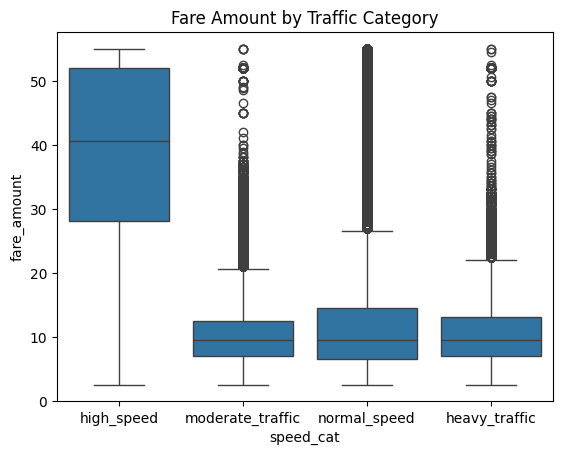

In [ ]:
sns.boxplot(data=df_record, x='speed_cat', y='fare_amount')

plt.title('Fare Amount by Traffic Category')
plt.show()

In [ ]:
"""
The Kruskal-Wallis test indicated a statistically significant difference
in fare distributions across traffic categories (p < 0.05). Trips classified
as high-speed showed substantially higher average fares compared to other traffic
conditions
"""

'\nThe Kruskal-Wallis test indicated a statistically significant difference \nin fare distributions across traffic categories (p < 0.05). Trips classified \nas high-speed showed substantially higher average fares compared to other traffic \nconditions\n'

In [24]:
# Daily trip count by vendor
daily_trip = (
    df_record
    .groupby(['pickup_date', 'vendor_id'])
    .size()
    .reset_index(name='trip_count')
)

# Separate vendors
vendor1 = daily_trip[daily_trip['vendor_id'] == '1']['trip_count']
vendor2 = daily_trip[daily_trip['vendor_id'] == '2']['trip_count']

# Statistical test
stat, p_value = mannwhitneyu(vendor1, vendor2)

vendor1_mean = vendor1.mean()
vendor2_mean = vendor2.mean()

print(f"P-value           : {p_value:.5f}")
print(f"Statistic          : {stat:.2f}")
print(f"Vendor 1 Mean      : {vendor1_mean:.2f} trips")
print(f"Vendor 2 Mean      : {vendor2_mean:.2f} trips")
print(f"Mean Difference   : {vendor1_mean - vendor2_mean:.2f} trips")

P-value           : 0.00000
Statistic          : 5009.00
Vendor 1 Mean      : 16977.59 trips
Vendor 2 Mean      : 19445.08 trips
Mean Difference   : -2467.49 trips


In [ ]:
"""
The Mann–Whitney U test indicated a statistically significant difference
in daily trip counts between Vendor 1 and Vendor 2 (p < 0.05). Vendor 2
showed a substantially higher average number of daily trips, handling
approximately 2,467 more trips per day compared to Vendor 1.
"""

#### Traffic Congestion Differences Between Weekdays and Weekends

In [ ]:
"""
Hypothesis 4:
Does traffic congestion differ between weekdays and weekends?
"""

table = pd.crosstab(
    df_record['is_weekend'],
    df_record['speed_cat']
)

chi2, p, dof, expected = chi2_contingency(table)

print(f"P-value : {p:.5f}")

P-value : 0.00000


In [ ]:
"""
Result:
The Chi-Square test indicated a statistically significant association
between day type (weekday/weekend) and traffic category (p < 0.05), suggesting
that traffic patterns differed between weekdays and weekends.
"""

## FARE PREDICTION MODEL

In [ ]:
print(f"dataset Shape    : {df_ml.shape}")

dataset Shape    : (6628926, 28)


In [ ]:
# Remove extrem outliers
df_model = df_ml[
    (df_ml['tip_amount'] <= df_ml['tip_amount'].quantile(0.99)) &
    (df_ml['trip_duration_minutes'] <= df_ml['trip_duration_minutes'].quantile(0.99)) &
    (df_ml['distance_km'] <= df_ml['distance_km'].quantile(0.99)) &
    (df_ml['payment_type'].isin(['1','2']))
].copy()

In [ ]:
# Remove geographics coordinates
df_model = df_model.drop(columns=[
    'pickup_longitude',
    'pickup_latitude',
    'dropoff_longitude',
    'dropoff_latitude'
])

In [ ]:
duplicate_pct = (df_model.duplicated().sum() / len(df_ml)) * 100

duplicate_pct

np.float64(0.08263782096828355)

Detected 5,492 duplicate rows (0.08% of total observations).
Duplicates were removed to improve data quality before statistical analysis and modeling.

In [ ]:
# remove duplicates
df_model = df_model.drop_duplicates()

In [ ]:
print(f"Final Shape    : {df_model.shape}")

Final Shape    : (6458574, 24)


In [ ]:
# feature selection
df_sample = df_model.sample(
    200000,
    random_state=42
)

In [ ]:
X = df_sample[
    [
        'vendor_id',
        'passenger_count',
        'distance_km',
        'rate_code',
        'payment_type',
        'pickup_hour',
        'trip_duration_minutes',
        'speed_kmh',
        'speed_cat',
        'day_name',
        'is_weekend'
    ]
]

# log transformation of target
y = np.log1p(df_sample['total_amount'])

In [ ]:
# one-hot encoding
X = pd.get_dummies(X, drop_first=True)

In [ ]:
# train-test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### MODEL TRAINING

In [ ]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("RMSE:", rmse_lr)
print("R2  :", r2_lr)
print()

Linear Regression
RMSE: 0.11845963276728298
R2  : 0.935551177993915



In [ ]:
# Decision Tree
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree")
print("RMSE:", rmse_dt)
print("R2  :", r2_dt)
print()

Decision Tree
RMSE: 0.08557658889527046
R2  : 0.9663655629920411



In [ ]:
# Random Forest
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)
print()

Random Forest
RMSE: 0.06293778251016646
R2  : 0.9818073026615252



In [ ]:
# XGBOOST
xgb = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=10,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost")
print("RMSE:", rmse_xgb)
print("R2  :", r2_xgb)
print()

XGBoost
RMSE: 0.06399272405154072
R2  : 0.981192311849668



In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest", "XGBoost"],
    "RMSE": [rmse_lr, rmse_dt, rmse_rf, rmse_xgb],
    "R2": [r2_lr, r2_dt, r2_rf, r2_xgb]
})

results.sort_values(by="RMSE")

,Model,RMSE,R2
2,Random Forest,0.06,0.98
3,XGBoost,0.06,0.98
1,Decision Tree,0.09,0.97
0,Linear Regression,0.12,0.94


In [ ]:
"""
Model Comparison Results:
- Linear Regression : 0.1171
- Decision Tree     : 0.0865
- Random Forest     : 0.0638
- XGBoost           : 0.0648

Random Forest achieved the lowest RMSE
"""

#### BEST MODEL EVALUATION

In [ ]:
# Prediction
y_pred_log = rf.predict(X_test)

# Back transform
y_pred_actual = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

print("Best model evaluation succeeded")

Best model evaluation succeeded


In [ ]:
# RMSE on actual scale
rmse_actual = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_pred_actual
    )
)

print(f"Actual Scale RMSE : {rmse_actual:.2f}")

Actual Scale RMSE : 1.32


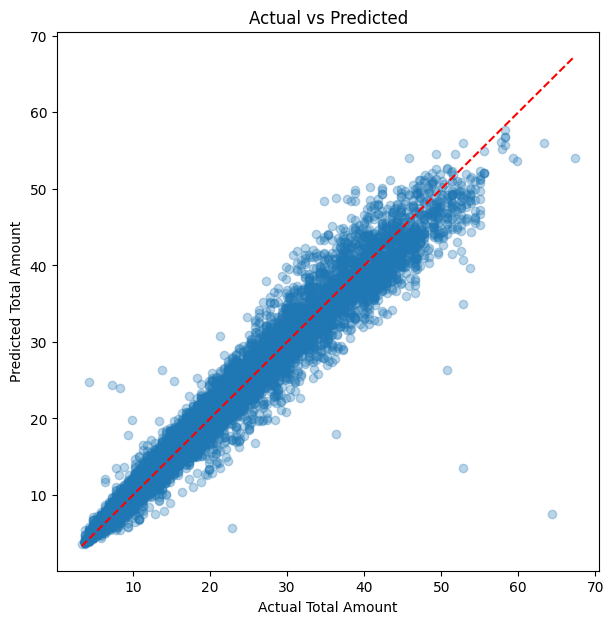

In [ ]:
# Actual vs Predicted Plot

plt.figure(figsize=(7,7))

plt.scatter(
    y_test_actual,
    y_pred_actual,
    alpha=0.3
)

# create prediction line
plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
    'r--'
)

plt.xlabel("Actual Total Amount")
plt.ylabel("Predicted Total Amount")

plt.title("Actual vs Predicted")

plt.show()

In [ ]:
"""
Most predictions closely followed the diagonal reference line,
indicating strong predictive performance from the Random Forest model.
"""

#### RESIDUAL PLOT

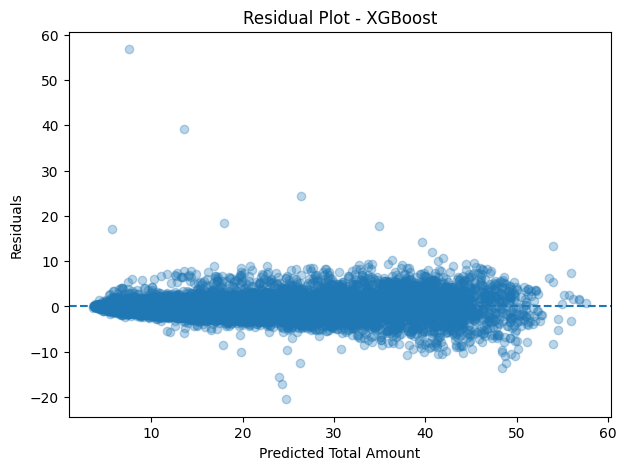

In [ ]:
# Residual = actual - predicted
residuals = y_test_actual - y_pred_actual

plt.figure(figsize=(7,5))

plt.scatter(
    y_pred_actual,
    residuals,
    alpha=0.3
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Total Amount")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

The residual plot showed that prediction errors were mostly centered around zero, indicating relatively stable model performance. However, higher fare trips exhibited greater residual dispersion, suggesting increased prediction variability for expensive or long-duration rides.

#### FEATURE IMPORTANCE

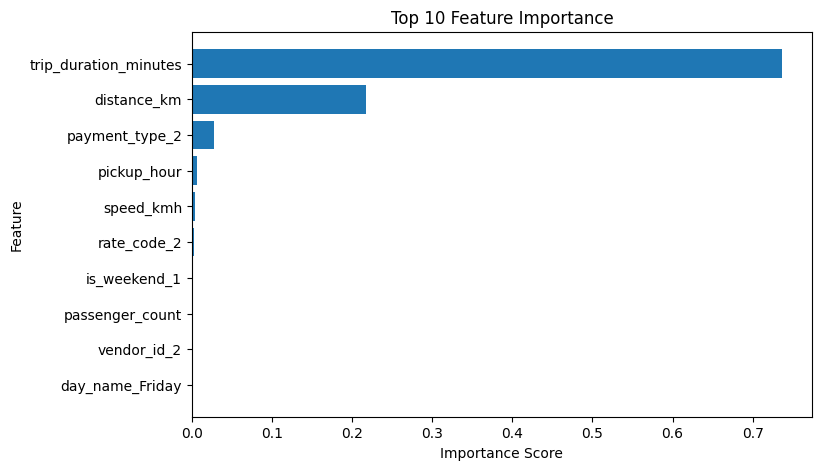

In [ ]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

# get the top 10
importance = importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

plt.figure(figsize=(8,5))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.gca().invert_yaxis()

plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.title("Top 10 Feature Importance")

plt.show()

In [ ]:

"""
Feature importance analysis showed that trip duration was the strongest predictor of total taxi fare,
followed by trip distance. This indicates that travel time plays a major role in fare estimation,
potentially reflecting the influence of traffic conditions and route characteristics on overall trip costs.
"""